In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
import ast
import matplotlib.pyplot as plt
import forestplot as fp
from scipy import stats

In [2]:
ancestry = pd.read_csv('/home/jupyter/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/ancestry/echo_v4_r2.ancestry_preds.tsv', sep='\t')
ancestry['pca_features'] = ancestry['pca_features'].apply(ast.literal_eval)
pca_df = pd.DataFrame(ancestry['pca_features'].tolist(), index=ancestry.index)
pca_df.columns = [f'PC{i+1}' for i in range(16)]
ancestry = pd.concat([ancestry.drop(columns=['pca_features']), pca_df], axis=1)
ancestry = ancestry[ancestry['ancestry_pred'] == ancestry['ancestry_pred_other']]
deprivation = pd.read_csv('../deprivation_index.tsv', sep='\t')

### eGFR

In [3]:
populations = ancestry.ancestry_pred.unique().tolist()
relatedness = pd.read_csv('~/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv', sep='\t')
t = 'eGFR'

In [4]:
def simplify_egfr_label(label):
    """
    Maps complex clinical eGFR concepts to concise, descriptive labels.
    """
    mapping = {
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD)',
        'Glomerular filtration rate/1.73 sq M.predicted among blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD, Black)',
        'Glomerular filtration rate/1.73 sq M.predicted among non-blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD, Non-Black)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI)',
        'Glomerular filtration rate/1.73 sq M.predicted among blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI, Black)',
        'Glomerular filtration rate/1.73 sq M.predicted among non-blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI, Non-Black)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI 2021)': 'eGFR (CKD-EPI 2021)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood': 'eGFR (General)',
        'Creatinine and Glomerular filtration rate.predicted panel - Serum, Plasma or Blood': 'eGFR (Panel)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_egfr_label)

In [5]:
trait_simplifiers = {
    'eGFR': simplify_egfr_label,
}

In [6]:
covariates = ['age_at_measurement', 'sex', 'deprivation_index', 'age_age', 'age_sex'] + [f'PC{i+1}' for i in range(16)]

    # 1. File loading (Consider changing to pd.read_parquet() for massive speedups!)
pgs = pd.read_csv(f'../score/{t}_baseline/genome_wide_pgs_filtered.tsv', sep='\t')
pheno = pd.read_csv(f'../Phenotype/{t}_new.tsv', sep='\t')
pheno = pheno[~pheno['id'].isin(relatedness['sample_id'])]
pheno['short_name'] = pheno["standard_concept_name"].apply(trait_simplifiers[t])

df = pgs.merge(pheno, left_on='#IID', right_on='id', how='inner')
df = df.merge(ancestry, left_on='#IID', right_on='research_id', how='inner')
df = df.merge(deprivation[['person_id', 'deprivation_index']], left_on='#IID', right_on='person_id', how='inner')

        # 3. Vectorize feature engineering
df['age_age'] = df['age_at_measurement'] ** 2 # slightly cleaner than multiplication
df['sex'] = df['sex_at_birth'].map({'Female': 0, 'Male': 1}).astype(float)
df['age_sex'] = df['age_at_measurement'] * df['sex']

cols_to_keep = ['#IID', 'ancestry_pred', 'ancestry_pred_other', 'phenotype', 'BETA_SUM', 'short_name'] + covariates
df_clean = df[cols_to_keep].dropna()
    
df_clean = df_clean[df_clean['ancestry_pred'] == 'afr']

if t == 'eGFR':
    df_clean = df_clean[~df_clean['short_name'].str.contains('Non-Black', na=False)]

In [7]:
def prioritize_eGFR_measurements(df_clean, include_red_quality=False):
  """Prioritizes and selects a single preferred eGFR measurement per individual

  based on exact blue vs. red circle tiers from the UpSet plot.
  """
  # True Blue Circle categories (high quality / consensus formulas)
  blue_categories = ['eGFR (CKD-EPI, Black)', 'eGFR (CKD-EPI 2021)', 'eGFR (CKD-EPI)']

  # Red Circle categories (Panel, General, and MDRD variants)
  red_categories = [
      'eGFR (Panel)',
      'eGFR (General)',
      'eGFR (MDRD)',
      'eGFR (MDRD, Black)',
  ]

  # Filter based on whether red quality is allowed
  if include_red_quality:
    allowed_categories = blue_categories + red_categories
  else:
    allowed_categories = blue_categories

  df_filtered = df_clean[df_clean['short_name'].isin(allowed_categories)].copy()

  # Your exact priority hierarchy:
  # 1. CKD-EPI, Black (Blue)
  # 2. CKD-EPI 2021 (Blue)
  # 3. CKD-EPI (Blue)
  # 4 & 5. Panel / General (Red - takes precedence over MDRDs)
  # 6. MDRD (Red)
  # 7. MDRD, Black (Red)
  priority_order = {
      'eGFR (CKD-EPI, Black)': 1,
      'eGFR (CKD-EPI 2021)': 2,
      'eGFR (CKD-EPI)': 3,
      'eGFR (Panel)': 4,
      'eGFR (General)': 5,
      'eGFR (MDRD)': 6,
      'eGFR (MDRD, Black)': 7,
  }

  df_filtered['priority'] = df_filtered['short_name'].map(priority_order)

  # Sort and drop duplicates to keep the highest priority measurement per individual
  df_sorted = df_filtered.sort_values(by=['#IID', 'priority'])
  df_prioritized = df_sorted.drop_duplicates(subset=['#IID'], keep='first')

  return df_prioritized

In [8]:
df_clean = df_clean[df_clean['phenotype'] < 1000]

In [9]:
df_blue_only = prioritize_eGFR_measurements(df_clean, include_red_quality=False)
df_blue_and_red = prioritize_eGFR_measurements(df_clean, include_red_quality=True)

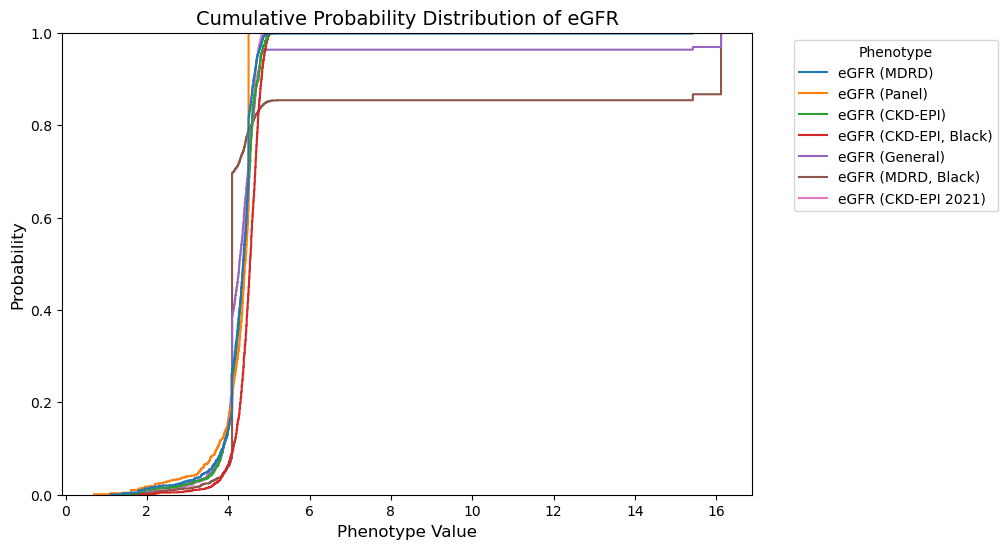

In [11]:
import seaborn as sns
plt.figure(figsize=(12, 6))

ax = sns.ecdfplot(
    data=df_blue_and_red,
    x='phenotype',
    hue='short_name'
    )
    
plt.title(f'Cumulative Probability Distribution of eGFR', fontsize=14)
plt.xlabel('Phenotype Value', fontsize=12)
plt.ylabel('Probability', fontsize=12)
    
# Move the legend outside
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1), title='Phenotype')

# Save and show
# Leave room for the legend so tight_layout doesn't squish the graph unevenly
plt.subplots_adjust(right=0.7) 
#plt.savefig(f'../eGFR_log_cum.pdf', bbox_inches='tight')
plt.show()

### Other three traits

In [12]:
def simplify_fev1_fvc_label(label):
    """
    Maps complex FEV1/FVC concepts to concise, descriptive labels.
    """
    mapping = {
        # Add any specific FEV1/FVC variants if needed, otherwise acts as a direct mapping/fallback
    }
    return mapping.get(label, label)

In [13]:
def simplify_ldlc_label(label):
    """
    Maps complex clinical LDL cholesterol concepts to concise, descriptive labels.
    """
    mapping = {
        'Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation': 'LDL-C (Calculation)',
        'Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay': 'LDL-C (Direct assay)',
        'Cholesterol in LDL [Mass/volume] in Serum or Plasma': 'LDL-C (General)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_ldlc_label)

In [14]:
def simplify_lymphocyte_label(label):
    """
    Maps complex clinical lymphocyte count concepts to concise, descriptive labels.
    """
    mapping = {
        'Lymphocytes [#/volume] in Blood by Automated count': 'Lymphocyte count (Automated)',
        'Lymphocytes [#/volume] in Blood by Manual count': 'Lymphocyte count (Manual)',
        'Lymphocytes [#/volume] in Blood': 'Lymphocyte count (General)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_lymphocyte_label)

In [15]:
trait_simplifiers = {
    'Lymphocyte_count': simplify_lymphocyte_label,
    'FEV1_FVC': simplify_fev1_fvc_label,
    'LDL_C': simplify_ldlc_label
}

In [16]:
traits = ['Lymphocyte_count','FEV1_FVC', 'LDL_C']
covariates = ['age_at_measurement', 'sex', 'deprivation_index', 'age_age', 'age_sex'] + [f'PC{i+1}' for i in range(16)]
overlap_dfs = []
pred_dfs = []
for t in traits:
    # 1. File loading (Consider changing to pd.read_parquet() for massive speedups!)
    pgs = pd.read_csv(f'../score/{t}_baseline/genome_wide_pgs_filtered.tsv', sep='\t')
    pheno = pd.read_csv(f'../Phenotype/{t}_new.tsv', sep='\t')
    pheno = pheno[~pheno['id'].isin(relatedness['sample_id'])]
    pheno['short_name'] = pheno["standard_concept_name"].apply(trait_simplifiers[t])
    if t == 'Lymphocyte_count':
        pheno = pheno[~pheno['standard_concept_name'].str.lower().str.contains('leukocytes', na=False)]
    #if t == 'eGFR':
        #pheno = pheno[~pheno['short_name'].str.contains('MDRD')]
    # 2. Merge efficiently using inner joins to automatically drop unmatched IDs
    df = pgs.merge(pheno, left_on='#IID', right_on='id', how='inner')
    df = df.merge(ancestry, left_on='#IID', right_on='research_id', how='inner')
    df = df.merge(deprivation[['person_id', 'deprivation_index']], left_on='#IID', right_on='person_id', how='inner')

        # 3. Vectorize feature engineering
    df['age_age'] = df['age_at_measurement'] ** 2 # slightly cleaner than multiplication
    df['sex'] = df['sex_at_birth'].map({'Female': 0, 'Male': 1}).astype(float)
    df['age_sex'] = df['age_at_measurement'] * df['sex']

    cols_to_keep = ['#IID', 'ancestry_pred', 'ancestry_pred_other', 'phenotype', 'BETA_SUM', 'short_name'] + covariates
    df_clean = df[cols_to_keep].dropna()
    
    df_clean = df_clean[df_clean['ancestry_pred'] == 'afr']

    if t == 'eGFR':
        df_clean = df_clean[~df_clean['short_name'].str.contains('Non-Black', na=False)]
    pivot_df = pd.crosstab(df_clean['#IID'], df_clean['short_name'])
    overlap_matrix = pivot_df.T.dot(pivot_df)
    overlap_dfs.append(overlap_matrix)
    pred_dfs.append(df_clean)
    #overlap_matrix.to_csv(f'{t}_overlap_matrix.tsv', sep='\t')

In [17]:
def greedy_phenotype_selection(df_patients, concept_columns):
    """
    df_patients: DataFrame where rows are individuals and columns are concept IDs 
                 containing boolean or binary values (True/False or 1/0) indicating presence.
    concept_columns: List of valid concept ID columns to consider.
    """
    uncovered_individuals = set(df_patients.index)
    selected_concepts = []
    
    while uncovered_individuals:
        best_concept = None
        best_new_individuals = set()
        
        # Find the concept that covers the maximum number of currently uncovered individuals
        for concept in concept_columns:
            if concept in selected_concepts:
                continue
                
            # Individuals who have this measurement and are still uncovered
            has_concept = set(df_patients.index[df_patients[concept] == 1])
            new_covered = has_concept.intersection(uncovered_individuals)
            
            if len(new_covered) > len(best_new_individuals):
                best_new_individuals = new_covered
                best_concept = concept
                
        # If no concept adds any new individuals, break out of the loop
        if not best_concept or not best_new_individuals:
            break
            
        selected_concepts.append(best_concept)
        # Remove newly covered individuals from the pool
        uncovered_individuals -= best_new_individuals
        
    return selected_concepts

In [18]:
non_overlapping_dfs = []
for i in np.arange(len(traits)):
    df_patients = pred_dfs[i][['#IID', 'short_name']].pivot_table(
    index='#IID', 
    columns='short_name', 
    aggfunc=lambda x: 1, # or len/count if you just want to check if an entry exists
    fill_value=0
    )
    
    concept_order = greedy_phenotype_selection(df_patients, pred_dfs[i].short_name.unique().tolist())
    concept_priority = {concept: i for i, concept in enumerate(concept_order)}

    pheno_df = pred_dfs[i].copy()
    
    pheno_df['priority'] = pheno_df['short_name'].map(concept_priority)
    pheno_df = pheno_df.sort_values(by=['#IID', 'priority'])
    
    non_overlapping_pheno = pheno_df.drop_duplicates(subset=['#IID'], keep='first')
    non_overlapping_pheno = non_overlapping_pheno.drop(columns=['priority'])

    non_overlapping_dfs.append(non_overlapping_pheno)  